In [1]:

from data_loader import DataLoader
from data_synthesizer.pipeline import  load_all_results

from evaluation_report.ressemblance_report import ResemblanceReport
from evaluation_report.utility_report import UtilityReport
from evaluation_report.privacy_report import PrivacyReport 
from evaluation_report.privacy_anonymeter_report import PrivacyAnonymeterReport


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import DATA_DIR, AIA_GUARD, BASELINE_DIR, RESULTS_DIR, UTILITY_ONLY_DIR, PRIVACY_ONLY_DIR


## Loading Data

In [3]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','default.payment.next.month']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)


In [4]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult)


In [5]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active','cardio']

df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio, sep = ',')
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio, sep = ',')


In [6]:
credit_ctgan_001_BILL_AMT3  = load_all_results(f'{AIA_GUARD}/credit_ctgan_aia_tau_0.01_sensitive_BILL_AMT3')
credit_ctgan_001_BILL_AMT5  = load_all_results(f'{AIA_GUARD}/credit_ctgan_aia_tau_0.01_sensitive_BILL_AMT5')
credit_ctgan_001_PAY_0  = load_all_results(f'{AIA_GUARD}/credit_ctgan_aia_tau_0.01_sensitive_PAY_0')
credit_ctgan_001_PAY_2  = load_all_results(f'{AIA_GUARD}/credit_ctgan_aia_tau_0.01_sensitive_PAY_2')
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_ctgan_privacy  = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline')
credit_ctgan_utility  = load_all_results(f'{UTILITY_ONLY_DIR}/credit_ctgan_baseline')

dict_results_credit_privacy_evaluation_results  = {
    'credit CTGAN' : credit_ctgan_privacy.privacy_evaluation_results.attribute_synthetic_prediction,
    'credit CTGAN 001 BILL_AMT3' : credit_ctgan_001_BILL_AMT3.privacy_evaluation_results.attribute_synthetic_prediction,
    'credit CTGAN 001 BILL_AMT5' : credit_ctgan_001_BILL_AMT5.privacy_evaluation_results.attribute_synthetic_prediction,
    'credit CTGAN 001 PAY_0' : credit_ctgan_001_PAY_0.privacy_evaluation_results.attribute_synthetic_prediction,
    'credit CTGAN 001 PAY_2' : credit_ctgan_001_PAY_2.privacy_evaluation_results.attribute_synthetic_prediction}

dict_results_credit_utility_evaluation_results  = {
    'credit TRTR' : credit_ctgan_utility.utility_evaluation_results.train_real_test_real_results,
    'credit CTGAN' : credit_ctgan_utility.utility_evaluation_results.train_synthetic_test_real_results,
    'credit CTGAN 001 BILL_AMT3' : credit_ctgan_001_BILL_AMT3.utility_evaluation_results.train_synthetic_test_real_results,
    'credit CTGAN 001 BILL_AMT5' : credit_ctgan_001_BILL_AMT5.utility_evaluation_results.train_synthetic_test_real_results,
    'credit CTGAN 001 PAY_0' : credit_ctgan_001_PAY_0.utility_evaluation_results.train_synthetic_test_real_results,
    'credit CTGAN 001 PAY_2' : credit_ctgan_001_PAY_2.utility_evaluation_results.train_synthetic_test_real_results}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [7]:
adult_ctgan_001_capital_gain  = load_all_results(f'{AIA_GUARD}/adult_ctgan_aia_tau_0.01_sensitive_capital-gain')
adult_ctgan_001_capital_loss  = load_all_results(f'{AIA_GUARD}/adult_ctgan_aia_tau_0.01_sensitive_capital-loss')
adult_ctgan_001_race  = load_all_results(f'{AIA_GUARD}/adult_ctgan_aia_tau_0.01_sensitive_race')
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline')
adult_ctgan_privacy  = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline')
adult_ctgan_utility  = load_all_results(f'{UTILITY_ONLY_DIR}/adult_ctgan_baseline')


dict_results_adult_privacy_evaluation_results  = {
    'adult CTGAN' : adult_ctgan_privacy.privacy_evaluation_results.attribute_synthetic_prediction,
    'adult CTGAN 001 capital-gain' : adult_ctgan_001_capital_gain.privacy_evaluation_results.attribute_synthetic_prediction,
    'adult CTGAN 001 capital-loss' : adult_ctgan_001_capital_loss.privacy_evaluation_results.attribute_synthetic_prediction,
    'adult CTGAN 001 race' : adult_ctgan_001_race.privacy_evaluation_results.attribute_synthetic_prediction}


dict_results_adult_utility_evaluation_results  = {
    'adult TRTR' : adult_ctgan_utility.utility_evaluation_results.train_real_test_real_results,
    'adult CTGAN' : adult_ctgan_utility.utility_evaluation_results.train_synthetic_test_real_results,
    'adult CTGAN 001 capital-gain' : adult_ctgan_001_capital_gain.utility_evaluation_results.train_synthetic_test_real_results,
    'adult CTGAN 001 capital-loss' : adult_ctgan_001_capital_loss.utility_evaluation_results.train_synthetic_test_real_results,
    'adult CTGAN 001 race' : adult_ctgan_001_race.utility_evaluation_results.train_synthetic_test_real_results}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [8]:
cardio_ctgan_001_ap_lo  = load_all_results(f'{AIA_GUARD}/cardio_ctgan_aia_tau_0.01_sensitive_ap_lo')
cardio_ctgan_001_ap_hi  = load_all_results(f'{AIA_GUARD}/cardio_ctgan_aia_tau_0.01_sensitive_ap_hi')
cardio_ctgan_001_cholesterol  = load_all_results(f'{AIA_GUARD}/cardio_ctgan_aia_tau_0.01_sensitive_cholesterol')
cardio_ctgan  = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline')
cardio_ctgan_privacy  = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline')
cardio_ctgan_utility  = load_all_results(f'{UTILITY_ONLY_DIR}/cardio_ctgan_baseline')

dict_results_cardio_privacy_evaluation_results  = {
    'cardio CTGAN' : cardio_ctgan_privacy.privacy_evaluation_results.attribute_synthetic_prediction,
    'cardio CTGAN 001 ap_lo' : cardio_ctgan_001_ap_lo.privacy_evaluation_results.attribute_synthetic_prediction,
    'cardio CTGAN 001 ap_hi' : cardio_ctgan_001_ap_hi.privacy_evaluation_results.attribute_synthetic_prediction,
    'cardio CTGAN 001 cholesterol' : cardio_ctgan_001_cholesterol.privacy_evaluation_results.attribute_synthetic_prediction}


dict_results_cardio_utility_evaluation_results  = {
    'cardio TRTR' : cardio_ctgan_utility.utility_evaluation_results.train_real_test_real_results,
    'cardio CTGAN' : cardio_ctgan_utility.utility_evaluation_results.train_synthetic_test_real_results,
    'cardio CTGAN 001 ap_lo' : cardio_ctgan_001_ap_lo.utility_evaluation_results.train_synthetic_test_real_results,
    'cardio CTGAN 001 ap_hi' : cardio_ctgan_001_ap_hi.utility_evaluation_results.train_synthetic_test_real_results,
    'cardio CTGAN 001 cholesterol' : cardio_ctgan_001_cholesterol.utility_evaluation_results.train_synthetic_test_real_results}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [10]:
aia_results = {}
aia_results.update(dict_results_credit_privacy_evaluation_results)
aia_results.update(dict_results_cardio_privacy_evaluation_results)
aia_results.update(dict_results_adult_privacy_evaluation_results)


utility_results = {}
utility_results.update(dict_results_credit_utility_evaluation_results)
utility_results.update(dict_results_cardio_utility_evaluation_results)
utility_results.update(dict_results_adult_utility_evaluation_results)

In [11]:
aia_results

{'credit CTGAN': {'BILL_AMT1': {'MSE': 5609510811.116152,
   'R2': -0.009138965996587256,
   'RMSE': 74896.66755681558},
  'BILL_AMT2': {'MSE': 5223051732.163548,
   'R2': -0.003168240636175934,
   'RMSE': 72270.68376709569},
  'BILL_AMT3': {'MSE': 4865710322.38508,
   'R2': -0.0022512981261919585,
   'RMSE': 69754.64373348258},
  'BILL_AMT4': {'MSE': 4286711757.3824744,
   'R2': -0.003271977995257247,
   'RMSE': 65472.98494327622},
  'BILL_AMT5': {'MSE': 3775003057.1607776,
   'R2': -0.00023720475658906004,
   'RMSE': 61441.05351603907},
  'BILL_AMT6': {'MSE': 3689638637.245487,
   'R2': -0.0037639396026660776,
   'RMSE': 60742.395715393766},
  'LIMIT_BAL': {'MSE': 14802200463.994925,
   'R2': 0.12133878592651204,
   'RMSE': 121664.29412113862},
  'PAY_0': {'Accuracy': 0.44316666666666665,
   'Balanced Accuracy': 0.11073471828500459,
   'Macro F1': 0.09223561798475788,
   'weighted F1': 0.36376445332094165,
   'weighted precision': 0.34428032091588134,
   'weighted recall': 0.44316666

In [16]:
xgb_only_series = {
    key: df.loc["XGBoost"]            # returns pd.Series
    for key, df in utility_results.items()
    if "XGBoost" in df.index
}
xgb_only_series

{'credit TRTR': accuracy_mean              0.822000
 accuracy_std               0.001179
 precision_avg_mean         0.668003
 precision_avg_std          0.005005
 recall_avg_mean            0.370982
 recall_avg_std             0.003644
 f1_avg_mean                0.477029
 f1_avg_std                 0.003862
 balanced_accuracy_mean     0.659664
 balanced_accuracy_std      0.001950
 precision_weighted_mean    0.804945
 precision_weighted_std     0.001587
 recall_weighted_mean       0.822000
 recall_weighted_std        0.001179
 f1_weighted_mean           0.801774
 f1_weighted_std            0.001356
 precision_macro_mean       0.755655
 precision_macro_std        0.002790
 recall_macro_mean          0.659664
 recall_macro_std           0.001950
 f1_macro_mean              0.684888
 f1_macro_std               0.002247
 roc_auc_mean               0.779165
 roc_auc_std                0.001080
 avg_precision_mean         0.546866
 avg_precision_std          0.001206
 mcc_mean              

In [31]:
import pandas as pd

def dict_to_df(results_dict):
    rows = []
    for model_name, features in results_dict.items():
        for feature, metrics in features.items():
            for metric_name, value in metrics.items():
                rows.append({
                    "model": model_name,
                    "feature": feature,
                    "metric": metric_name,
                    "value": value
                })
    return pd.DataFrame(rows)

df_results_credit_privacy_evaluation_results = dict_to_df(dict_results_credit_privacy_evaluation_results)


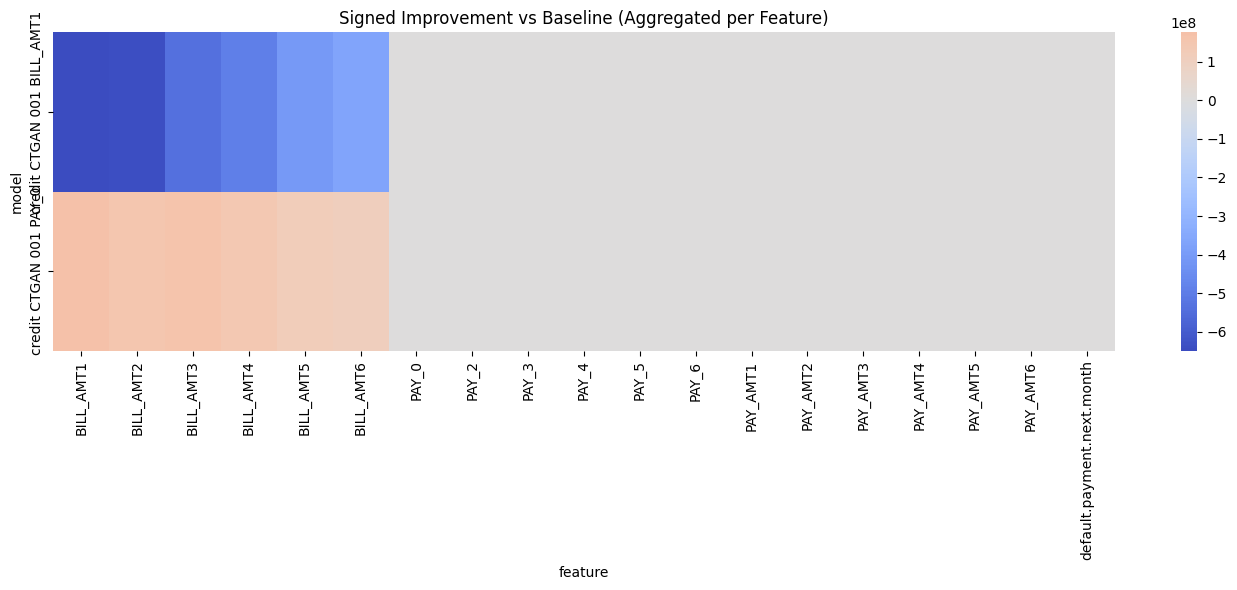

In [35]:
df = df_results_credit_privacy_evaluation_results
baseline_name = "credit CTGAN"

baseline = df[df.model == baseline_name][
    ["feature", "metric", "value"]
].rename(columns={"value": "baseline_value"})

df = df.merge(baseline, on=["feature", "metric"])

higher_is_better = {
    "R2": True,
    "Accuracy": True,
    "Balanced Accuracy": True,
    "Macro F1": True,
    "weighted F1": True,
    "weighted precision": True,
    "weighted recall": True,
    "MSE": False,
    "RMSE": False,
}

def signed_improvement(row):
    if higher_is_better[row.metric]:
        return row.value - row.baseline_value
    else:
        return row.baseline_value - row.value

df["improvement"] = df.apply(signed_improvement, axis=1)

agg = (
    df[df.model != baseline_name]
    .groupby(["model", "feature"])["improvement"]
    .mean()
    .reset_index()
)

import seaborn as sns
import matplotlib.pyplot as plt

pivot = agg.pivot(index="model", columns="feature", values="improvement")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, center=0, cmap="coolwarm", annot=False)
plt.title("Signed Improvement vs Baseline (Aggregated per Feature)")
plt.tight_layout()
plt.show()



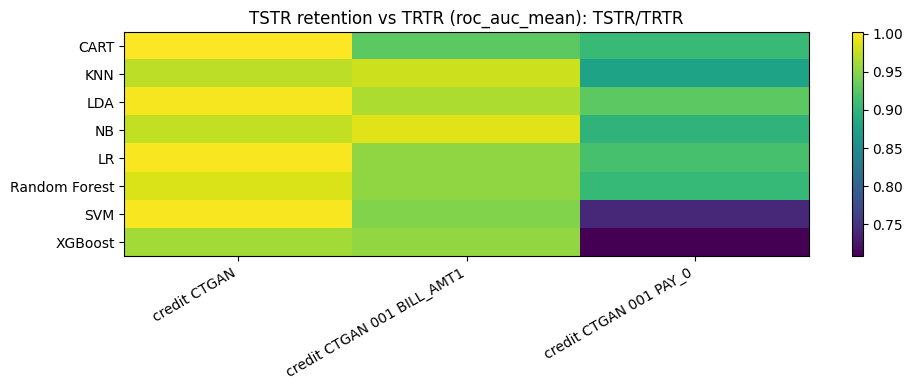

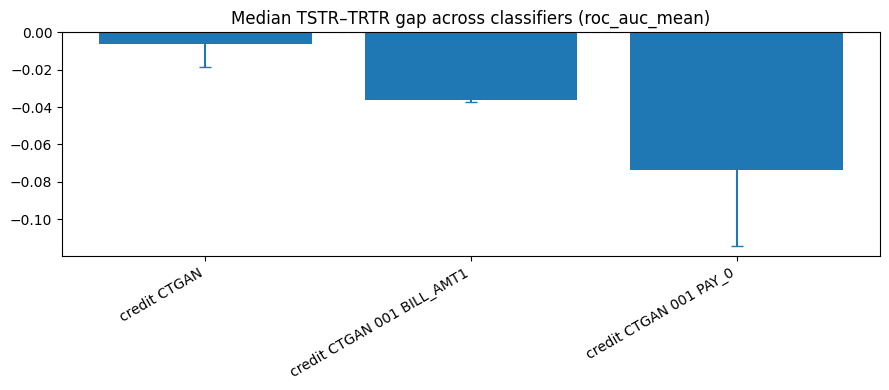

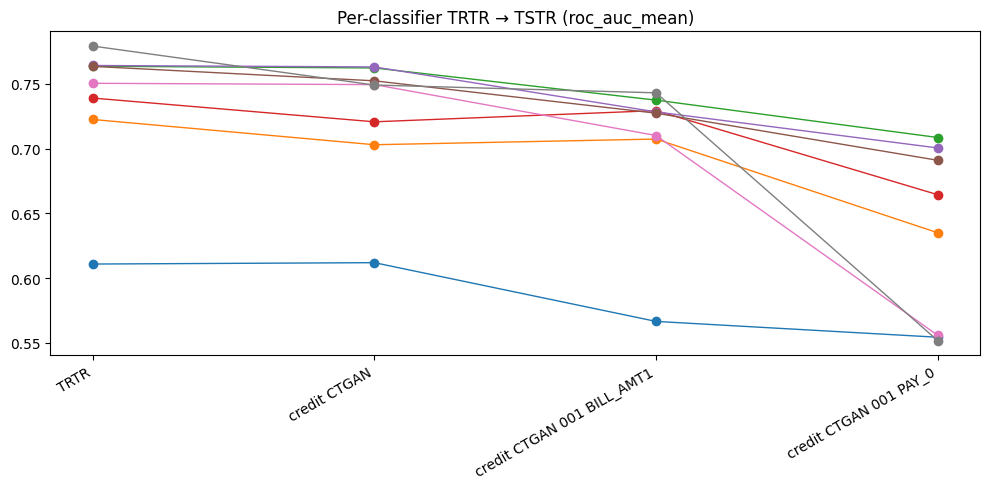

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tstr_dict = dict_results_credit_utility_evaluation_results  # <- replace

TRTR_KEY = "credit TRTR"
baseline = tstr_dict[TRTR_KEY]

def extract_metric(df, metric_mean_col):
    # returns Series indexed by classifier
    return df[metric_mean_col]

def retention_table(tstr_dict, metric_mean_col):
    trtr = extract_metric(tstr_dict[TRTR_KEY], metric_mean_col)
    out = {}
    for name, df in tstr_dict.items():
        if name == TRTR_KEY:
            continue
        tstr = extract_metric(df, metric_mean_col)
        out[name] = (tstr / trtr).replace([np.inf, -np.inf], np.nan)
    return pd.DataFrame(out)  # index=classifier, columns=generators

def gap_table(tstr_dict, metric_mean_col):
    trtr = extract_metric(tstr_dict[TRTR_KEY], metric_mean_col)
    out = {}
    for name, df in tstr_dict.items():
        if name == TRTR_KEY:
            continue
        tstr = extract_metric(df, metric_mean_col)
        out[name] = (tstr - trtr)
    return pd.DataFrame(out)

# ---- Choose your primary metric here ----
metric = "roc_auc_mean"  # or "avg_precision_mean" or "balanced_accuracy_mean"

ret = retention_table(tstr_dict, metric)
gap = gap_table(tstr_dict, metric)

# ---------------------------
# Plot A: Retention heatmap (matplotlib imshow)
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ret.values, aspect="auto")
ax.set_yticks(np.arange(ret.shape[0]))
ax.set_yticklabels(ret.index)
ax.set_xticks(np.arange(ret.shape[1]))
ax.set_xticklabels(ret.columns, rotation=30, ha="right")
ax.set_title(f"TSTR retention vs TRTR ({metric}): TSTR/TRTR")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot B: Median gap across classifiers (with IQR)
# ---------------------------
med = gap.median(axis=0)
q1 = gap.quantile(0.25, axis=0)
q3 = gap.quantile(0.75, axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(med.index))
ax.bar(x, med.values)
ax.errorbar(x, med.values, yerr=[(med - q1).values, (q3 - med).values], fmt="none", capsize=4)
ax.axhline(0, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(med.index, rotation=30, ha="right")
ax.set_title(f"Median TSTR–TRTR gap across classifiers ({metric})")
plt.tight_layout()
plt.show()

# ---------------------------
# Plot C: Per-classifier slope plot (TRTR -> each generator)
# ---------------------------
trtr_vals = extract_metric(tstr_dict[TRTR_KEY], metric)

fig, ax = plt.subplots(figsize=(10, 5))
gens = list(ret.columns)
for clf in ret.index:
    y0 = trtr_vals.loc[clf]
    ys = [tstr_dict[g].loc[clf, metric] for g in gens]
    ax.plot([0] + list(range(1, len(gens)+1)), [y0] + ys, marker="o", linewidth=1)

ax.set_xticks(range(0, len(gens)+1))
ax.set_xticklabels(["TRTR"] + gens, rotation=30, ha="right")
ax.set_title(f"Per-classifier TRTR → TSTR ({metric})")
plt.tight_layout()
plt.show()


In [56]:
"""
Paper-ready evaluation plots for AIA + utility trade-offs.

Assumptions:
- You will paste your objects into:
    aia_results = {...}
    utility_results = {...}
  where:
    * aia_results[method_key][feature] = {metric_name: value, ...}
    * utility_results[method_key] is a pandas.DataFrame (rows=downstream models, cols like accuracy_mean, accuracy_std, ...)

Outputs:
- Saves figures into ./figures/:
    Figure1_targeted_AIA.(png/pdf)
    Figure2_AIA_side_effects_heatmaps.(png/pdf)
    Figure3_utility_key_metrics.(png/pdf)
    Figure4_privacy_utility_frontier.(png/pdf)
  Plus optional per-model utility plots (one per dataset) if enabled.

- Prints a compact summary table of:
    * targeted AIA deltas vs baseline
    * key utility deltas vs baseline
    * trade-off coordinates used in Figure 4

Dependencies: numpy, pandas, matplotlib only.
"""

import os
import re
import math
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


# =========================
# USER MUST PROVIDE THESE:
# =========================
# aia_results = {...}
# utility_results = {...}

# =========================
# CONFIG / SPECS
# =========================

DATASET_SPECS = {
    "credit": {"numeric_target": "BILL_AMT3", "categorical_target": "PAY_0"},
    "cardio": {"numeric_target": "ap_lo", "categorical_target": "cholesterol"},
    "adult": {"numeric_target": "capital-gain", "categorical_target": "race"},
}

# AIA canonical metrics we expect
AIA_NUMERIC_METRICS_REQUIRED = ("RMSE", "R2")
AIA_CATEGORICAL_METRICS_REQUIRED = ("Balanced Accuracy", "Macro F1")

# Utility metrics (base names) used in Figure 3 and Figure 4 aggregation
UTILITY_KEY_METRICS = ["accuracy", "f1_avg", "balanced_accuracy", "roc_auc", "log_loss"]
UTILITY_DIRECTION = {
    "accuracy": "higher",
    "f1_avg": "higher",
    "balanced_accuracy": "higher",
    "roc_auc": "higher",
    "log_loss": "lower",
}

# Plotting controls
OUTDIR = "./figures"
SAVE_DPI = 350
MAKE_OPTIONAL_PER_MODEL_UTILITY_PLOTS = True  # optional but desirable


# =========================
# STYLE (matplotlib only)
# =========================
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": SAVE_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# HELPERS: input coercion
# =========================
def _merge_if_sequence(obj: Any, name: str) -> Dict[str, Any]:
    """
    Allows aia_results / utility_results to be provided either as:
      - dict
      - list/tuple of dicts (which we merge, requiring no overlapping keys)
    """
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, (list, tuple)):
        merged: Dict[str, Any] = {}
        for i, d in enumerate(obj):
            if not isinstance(d, dict):
                raise TypeError(f"{name}[{i}] must be a dict, got {type(d)}")
            overlap = set(merged).intersection(d)
            if overlap:
                raise ValueError(f"{name} has overlapping keys across dicts: {sorted(overlap)[:10]}")
            merged.update(d)
        return merged
    raise TypeError(f"{name} must be a dict or a list/tuple of dicts, got {type(obj)}")


def _coerce_df(obj: Any, ctx: str) -> pd.DataFrame:
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    if isinstance(obj, dict):
        return pd.DataFrame(obj).copy()
    raise TypeError(f"{ctx} must be a pandas.DataFrame or dict, got {type(obj)}")


# =========================
# HELPERS: key parsing
# =========================
def parse_method_key(method_key: str) -> Dict[str, Optional[str]]:
    """
    Expected patterns (examples):
      - "credit CTGAN"                         -> baseline
      - "credit CTGAN 001 BILL_AMT3"           -> postproc targeting BILL_AMT3
      - "credit CTGAN 001 PAY_0"               -> postproc targeting PAY_0
      - "credit TRTR"                          -> real baseline
    """
    if not isinstance(method_key, str) or not method_key.strip():
        raise ValueError(f"Invalid method_key: {method_key!r}")
    s = method_key.strip()
    parts = s.split()
    if len(parts) < 2:
        raise ValueError(f"method_key must have at least 2 tokens: {method_key!r}")

    dataset = parts[0]
    second = parts[1]

    if second.upper() == "TRTR":
        return {
            "dataset": dataset,
            "generator": "TRTR",
            "kind": "TRTR",
            "postproc_target": None,
            "method_key": s,
        }

    generator = second
    if "001" in parts:
        idx = parts.index("001")
        target = " ".join(parts[idx + 1:]).strip()
        if not target:
            raise ValueError(f"Postproc method_key missing target after '001': {method_key!r}")
        return {
            "dataset": dataset,
            "generator": generator,
            "kind": "postproc",
            "postproc_target": target,
            "method_key": s,
        }

    return {
        "dataset": dataset,
        "generator": generator,
        "kind": "baseline",
        "postproc_target": None,
        "method_key": s,
    }


# =========================
# AIA: parsing + accessors
# =========================
def aia_to_long_df(aia_results_in: Any) -> pd.DataFrame:
    aia = _merge_if_sequence(aia_results_in, "aia_results")
    records: List[Dict[str, Any]] = []

    for mkey, feat_map in aia.items():
        meta = parse_method_key(str(mkey))
        if not isinstance(feat_map, dict):
            raise TypeError(f"AIA entry for {mkey!r} must be dict(feature -> metrics), got {type(feat_map)}")

        for feat, metrics in feat_map.items():
            if not isinstance(metrics, dict):
                raise TypeError(f"AIA metrics for {mkey!r}/{feat!r} must be dict, got {type(metrics)}")
            metric_keys = set(metrics.keys())

            if any(k in metric_keys for k in ("RMSE", "MSE", "R2")):
                ftype = "numeric"
            elif any(k in metric_keys for k in ("Balanced Accuracy", "Macro F1", "Accuracy", "weighted F1")):
                ftype = "categorical"
            else:
                raise ValueError(
                    f"Cannot infer feature type for AIA {mkey!r}/{feat!r}. Metric keys: {sorted(metric_keys)}"
                )

            for metric_name, val in metrics.items():
                records.append({
                    "dataset": meta["dataset"],
                    "generator": meta["generator"],
                    "kind": meta["kind"],
                    "postproc_target": meta["postproc_target"],
                    "method_key": meta["method_key"],
                    "feature": str(feat),
                    "feature_type": ftype,
                    "metric": str(metric_name),
                    "value": float(val) if val is not None and not (isinstance(val, float) and np.isnan(val)) else np.nan,
                })

    df = pd.DataFrame.from_records(records)
    if df.empty:
        raise ValueError("Parsed AIA dataframe is empty. Check aia_results formatting.")
    return df


def _aia_get_value(aia_long: pd.DataFrame, method_key: str, feature: str, metric: str) -> float:
    sub = aia_long[
        (aia_long["method_key"] == method_key) &
        (aia_long["feature"] == feature) &
        (aia_long["metric"] == metric)
    ]
    if len(sub) != 1:
        available = aia_long[aia_long["method_key"] == method_key]["feature"].unique().tolist()
        raise KeyError(
            f"Expected exactly 1 AIA value for method={method_key!r}, feature={feature!r}, metric={metric!r}; "
            f"found {len(sub)}. Available features for this method: {available[:20]}"
        )
    v = float(sub["value"].iloc[0])
    if not np.isfinite(v):
        raise ValueError(f"AIA value is not finite for method={method_key!r}, feature={feature!r}, metric={metric!r}")
    return v


def _select_required_method_keys(aia_long: pd.DataFrame, utility_summary: pd.DataFrame, dataset: str) -> Dict[str, str]:
    """
    Selects:
      - baseline synthetic key for this dataset
      - postproc key targeting numeric sensitive feature
      - postproc key targeting categorical sensitive feature
      - trtr key (if present in utility_summary)
    Enforces existence for required keys, and raises with useful context.
    """
    if dataset not in DATASET_SPECS:
        raise KeyError(f"Unknown dataset {dataset!r}. Known: {sorted(DATASET_SPECS)}")

    num_t = DATASET_SPECS[dataset]["numeric_target"]
    cat_t = DATASET_SPECS[dataset]["categorical_target"]

    # Baseline synthetic (AIA must have it for privacy plots)
    cand_base = aia_long[(aia_long["dataset"] == dataset) & (aia_long["kind"] == "baseline")]["method_key"].unique().tolist()
    if len(cand_base) != 1:
        raise ValueError(
            f"Expected exactly 1 baseline AIA method_key for dataset={dataset!r}, found {len(cand_base)}: {cand_base}"
        )
    baseline_key = cand_base[0]

    cand_pp_num = aia_long[
        (aia_long["dataset"] == dataset) &
        (aia_long["kind"] == "postproc") &
        (aia_long["postproc_target"] == num_t)
    ]["method_key"].unique().tolist()
    if len(cand_pp_num) != 1:
        available_targets = sorted(aia_long[(aia_long["dataset"] == dataset) & (aia_long["kind"] == "postproc")]["postproc_target"].dropna().unique().tolist())
        raise ValueError(
            f"Expected exactly 1 postproc AIA key targeting numeric target {num_t!r} for dataset={dataset!r}, "
            f"found {len(cand_pp_num)}: {cand_pp_num}. Available postproc targets: {available_targets}"
        )
    pp_num_key = cand_pp_num[0]

    cand_pp_cat = aia_long[
        (aia_long["dataset"] == dataset) &
        (aia_long["kind"] == "postproc") &
        (aia_long["postproc_target"] == cat_t)
    ]["method_key"].unique().tolist()
    if len(cand_pp_cat) != 1:
        available_targets = sorted(aia_long[(aia_long["dataset"] == dataset) & (aia_long["kind"] == "postproc")]["postproc_target"].dropna().unique().tolist())
        raise ValueError(
            f"Expected exactly 1 postproc AIA key targeting categorical target {cat_t!r} for dataset={dataset!r}, "
            f"found {len(cand_pp_cat)}: {cand_pp_cat}. Available postproc targets: {available_targets}"
        )
    pp_cat_key = cand_pp_cat[0]

    # Utility TRTR key (utility-only; AIA may not contain TRTR)
    cand_trtr = utility_summary[
        (utility_summary["dataset"] == dataset) &
        (utility_summary["kind"] == "TRTR")
    ]["method_key"].unique().tolist()
    trtr_key = cand_trtr[0] if len(cand_trtr) == 1 else ""

    return {"baseline": baseline_key, "pp_numeric": pp_num_key, "pp_categorical": pp_cat_key, "trtr": trtr_key}


# =========================
# Utility: aggregation + accessors
# =========================
def build_utility_summary(utility_results_in: Any, metrics_base: List[str]) -> pd.DataFrame:
    util = _merge_if_sequence(utility_results_in, "utility_results")
    rows: List[Dict[str, Any]] = []

    for mkey, df_obj in util.items():
        meta = parse_method_key(str(mkey))
        df = _coerce_df(df_obj, ctx=f"utility_results[{mkey!r}]")
        df = df.copy()
        df.index = df.index.map(str)

        # coerce columns numeric where possible
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        row: Dict[str, Any] = dict(meta)
        row["n_models"] = int(len(df))

        for mb in metrics_base:
            mean_col = f"{mb}_mean"
            std_col = f"{mb}_std"

            if mean_col not in df.columns:
                # allow missing metrics; keep NaN
                row[mean_col] = np.nan
                row[std_col] = np.nan
                continue

            vals = df[mean_col].to_numpy(dtype=float)
            row[mean_col] = float(np.nanmean(vals))

            if std_col in df.columns:
                std_vals = df[std_col].to_numpy(dtype=float)
                # Approximate std for the mean-across-models: SE-like pooling
                n_eff = int(np.sum(np.isfinite(std_vals)))
                if n_eff > 0:
                    row[std_col] = float(np.sqrt(np.nanmean(std_vals ** 2) / n_eff))
                else:
                    row[std_col] = np.nan
            else:
                row[std_col] = np.nan

        rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError("Parsed utility summary is empty. Check utility_results formatting.")
    return out


def _util_get(utility_summary: pd.DataFrame, method_key: str, metric_base: str, stat: str = "mean") -> float:
    col = f"{metric_base}_{stat}"
    sub = utility_summary[utility_summary["method_key"] == method_key]
    if len(sub) != 1:
        raise KeyError(f"Expected exactly 1 utility summary row for method_key={method_key!r}, found {len(sub)}")
    v = float(sub[col].iloc[0])
    if not np.isfinite(v):
        raise ValueError(f"Utility value not finite for method={method_key!r}, col={col!r}")
    return v


# =========================
# Delta computations (direction-aware)
# =========================
def privacy_gain_pct_for_feature(
    aia_long: pd.DataFrame,
    baseline_key: str,
    method_key: str,
    feature: str,
    feature_type: str,
) -> float:
    """
    Returns direction-corrected privacy gain percentage:
      - numeric features: uses RMSE, higher RMSE => better privacy
            gain% = (RMSE_post - RMSE_base) / RMSE_base * 100
      - categorical features: uses Balanced Accuracy, lower BA => better privacy
            gain% = (BA_base - BA_post) / BA_base * 100
    Positive => improved privacy; negative => worse privacy.
    """
    if feature_type == "numeric":
        base = _aia_get_value(aia_long, baseline_key, feature, "RMSE")
        post = _aia_get_value(aia_long, method_key, feature, "RMSE")
        if base <= 0:
            raise ValueError(f"Baseline RMSE must be >0 for feature={feature!r}, got {base}")
        return 100.0 * (post - base) / base

    if feature_type == "categorical":
        base = _aia_get_value(aia_long, baseline_key, feature, "Balanced Accuracy")
        post = _aia_get_value(aia_long, method_key, feature, "Balanced Accuracy")
        if base <= 0:
            raise ValueError(f"Baseline Balanced Accuracy must be >0 for feature={feature!r}, got {base}")
        return 100.0 * (base - post) / base

    raise ValueError(f"Unknown feature_type={feature_type!r}")


def utility_drop_pct(
    utility_summary: pd.DataFrame,
    baseline_key: str,
    method_key: str,
    metrics_base: List[str],
) -> Tuple[float, Dict[str, float]]:
    """
    Direction-corrected utility drop (%) vs baseline synthetic.
      - higher-is-better metrics: drop% = (base - post)/base * 100
      - lower-is-better metrics:  drop% = (post - base)/base * 100
    Returns:
      (overall_drop_pct_avg, per_metric_drop_pct_dict)
    """
    drops: Dict[str, float] = {}
    for mb in metrics_base:
        base = _util_get(utility_summary, baseline_key, mb, "mean")
        post = _util_get(utility_summary, method_key, mb, "mean")
        if not np.isfinite(base) or base == 0:
            drops[mb] = np.nan
            continue
        if UTILITY_DIRECTION[mb] == "higher":
            drops[mb] = 100.0 * (base - post) / base
        else:
            drops[mb] = 100.0 * (post - base) / base

    overall = float(np.nanmean(list(drops.values())))
    return overall, drops


# =========================
# PLOTTING: save helper
# =========================
def _ensure_outdir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def _save_fig(fig: plt.Figure, outdir: str, stem: str) -> None:
    _ensure_outdir(outdir)
    png = os.path.join(outdir, f"{stem}.png")
    pdf = os.path.join(outdir, f"{stem}.pdf")
    fig.savefig(png, bbox_inches="tight", dpi=SAVE_DPI)
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)


# =========================
# FIGURE 1: targeted AIA
# =========================
def plot_figure1_targeted_aia(aia_long: pd.DataFrame, method_keys: Dict[str, Dict[str, str]], outdir: str) -> None:
    datasets = list(DATASET_SPECS.keys())
    fig, axes = plt.subplots(nrows=len(datasets), ncols=2, figsize=(11.0, 8.5), constrained_layout=True)

    for r, ds in enumerate(datasets):
        keys = method_keys[ds]
        base_k = keys["baseline"]
        pp_num_k = keys["pp_numeric"]
        pp_cat_k = keys["pp_categorical"]

        num_t = DATASET_SPECS[ds]["numeric_target"]
        cat_t = DATASET_SPECS[ds]["categorical_target"]

        # ---- numeric target: use R2 ----
        ax = axes[r, 0]
        # required checks
        for m in AIA_NUMERIC_METRICS_REQUIRED:
            _ = _aia_get_value(aia_long, base_k, num_t, m)
            _ = _aia_get_value(aia_long, pp_num_k, num_t, m)

        r2_base = _aia_get_value(aia_long, base_k, num_t, "R2")
        r2_post = _aia_get_value(aia_long, pp_num_k, num_t, "R2")
        vals = [r2_base, r2_post]
        labels = ["Baseline syn", "Postproc (target numeric)"]
        ax.bar(np.arange(2), vals)
        ax.set_xticks(np.arange(2))
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.set_ylabel("AIA $R^2$ (higher = stronger attacker)")
        ax.axhline(0.0, linewidth=1.0)
        ax.set_title(f"{ds}: numeric sensitive = {num_t}")
        delta = r2_post - r2_base
        ax.text(0.02, 0.95, f"ΔR² (post-base) = {delta:+.3f}\n(↓ is privacy gain)",
                transform=ax.transAxes, va="top")

        # ---- categorical target: Balanced Accuracy + Macro F1 ----
        ax = axes[r, 1]
        for m in AIA_CATEGORICAL_METRICS_REQUIRED:
            _ = _aia_get_value(aia_long, base_k, cat_t, m)
            _ = _aia_get_value(aia_long, pp_cat_k, cat_t, m)

        ba_base = _aia_get_value(aia_long, base_k, cat_t, "Balanced Accuracy")
        ba_post = _aia_get_value(aia_long, pp_cat_k, cat_t, "Balanced Accuracy")
        f1_base = _aia_get_value(aia_long, base_k, cat_t, "Macro F1")
        f1_post = _aia_get_value(aia_long, pp_cat_k, cat_t, "Macro F1")

        metrics = ["Balanced Acc", "Macro F1"]
        x = np.arange(len(metrics))
        width = 0.36
        ax.bar(x - width/2, [ba_base, f1_base], width, label="Baseline syn")
        ax.bar(x + width/2, [ba_post, f1_post], width, label="Postproc (target categorical)")
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylabel("AIA score (higher = stronger attacker)")
        ax.set_title(f"{ds}: categorical sensitive = {cat_t}")

        d_ba = ba_post - ba_base
        d_f1 = f1_post - f1_base
        ax.text(0.02, 0.95, f"ΔBA = {d_ba:+.3f}, ΔMacroF1 = {d_f1:+.3f}\n(↓ is privacy gain)",
                transform=ax.transAxes, va="top")

        if r == 0:
            ax.legend(loc="lower left", frameon=False)

    _save_fig(fig, outdir, "Figure1_targeted_AIA")


# =========================
# FIGURE 2: heatmaps side effects
# =========================
def plot_figure2_side_effect_heatmaps(aia_long: pd.DataFrame, method_keys: Dict[str, Dict[str, str]], outdir: str) -> None:
    datasets = list(DATASET_SPECS.keys())

    # Build matrices for all datasets first to set consistent color scaling
    mats_numeric: Dict[str, pd.DataFrame] = {}
    mats_categorical: Dict[str, pd.DataFrame] = {}
    max_abs_numeric = 0.0
    max_abs_categorical = 0.0

    for ds in datasets:
        keys = method_keys[ds]
        base_k = keys["baseline"]
        pp_num_k = keys["pp_numeric"]
        pp_cat_k = keys["pp_categorical"]

        # Determine feature lists from baseline
        base_feats = aia_long[(aia_long["method_key"] == base_k)][["feature", "feature_type"]].drop_duplicates()
        num_feats = base_feats[base_feats["feature_type"] == "numeric"]["feature"].tolist()
        cat_feats = base_feats[base_feats["feature_type"] == "categorical"]["feature"].tolist()

        # Create per-feature privacy gain (%) matrices
        num_rows = []
        for f in num_feats:
            try:
                g_num = privacy_gain_pct_for_feature(aia_long, base_k, pp_num_k, f, "numeric")
                g_cat = privacy_gain_pct_for_feature(aia_long, base_k, pp_cat_k, f, "numeric")
            except Exception:
                g_num, g_cat = np.nan, np.nan
            num_rows.append((f, g_num, g_cat))

        cat_rows = []
        for f in cat_feats:
            try:
                g_num = privacy_gain_pct_for_feature(aia_long, base_k, pp_num_k, f, "categorical")
                g_cat = privacy_gain_pct_for_feature(aia_long, base_k, pp_cat_k, f, "categorical")
            except Exception:
                g_num, g_cat = np.nan, np.nan
            cat_rows.append((f, g_num, g_cat))

        num_df = pd.DataFrame(num_rows, columns=["feature", "Postproc numeric", "Postproc categorical"]).set_index("feature")
        cat_df = pd.DataFrame(cat_rows, columns=["feature", "Postproc numeric", "Postproc categorical"]).set_index("feature")

        # Mark sensitive targets with asterisk in index labels (label-only; values unchanged)
        num_t = DATASET_SPECS[ds]["numeric_target"]
        cat_t = DATASET_SPECS[ds]["categorical_target"]
        if num_t in num_df.index:
            num_df = num_df.rename(index={num_t: f"*{num_t}"})
        if cat_t in cat_df.index:
            cat_df = cat_df.rename(index={cat_t: f"*{cat_t}"})

        mats_numeric[ds] = num_df
        mats_categorical[ds] = cat_df

        if np.isfinite(num_df.to_numpy(dtype=float)).any():
            max_abs_numeric = max(max_abs_numeric, float(np.nanmax(np.abs(num_df.to_numpy(dtype=float)))))
        if np.isfinite(cat_df.to_numpy(dtype=float)).any():
            max_abs_categorical = max(max_abs_categorical, float(np.nanmax(np.abs(cat_df.to_numpy(dtype=float)))))

    # Plot: 2 rows (numeric/categorical) x 3 cols (datasets)
    fig, axes = plt.subplots(nrows=2, ncols=len(datasets), figsize=(14.5, 8.5), constrained_layout=True)

    # Use a diverging colormap centered at 0
    cmap = mpl.colormaps.get("coolwarm")

    for c, ds in enumerate(datasets):
        # ---- numeric ----
        ax = axes[0, c]
        mat = mats_numeric[ds]
        arr = mat.to_numpy(dtype=float)
        im = ax.imshow(arr, aspect="auto", interpolation="nearest",
                       vmin=-max_abs_numeric, vmax=max_abs_numeric, cmap=cmap)
        ax.set_title(f"{ds} (numeric features)\nprivacy gain % via RMSE")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(list(mat.columns), rotation=20, ha="right")
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index)

        # ---- categorical ----
        ax = axes[1, c]
        mat = mats_categorical[ds]
        arr = mat.to_numpy(dtype=float)
        im2 = ax.imshow(arr, aspect="auto", interpolation="nearest",
                        vmin=-max_abs_categorical, vmax=max_abs_categorical, cmap=cmap)
        ax.set_title(f"{ds} (categorical features)\nprivacy gain % via Balanced Acc")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(list(mat.columns), rotation=20, ha="right")
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index)

    # Colorbars (one per row)
    cbar1 = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=-max_abs_numeric, vmax=max_abs_numeric), cmap=cmap),
                         ax=axes[0, :], shrink=0.85, location="right", pad=0.02)
    cbar1.set_label("Privacy gain (%)  —  positive = improved privacy")

    cbar2 = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=-max_abs_categorical, vmax=max_abs_categorical), cmap=cmap),
                         ax=axes[1, :], shrink=0.85, location="right", pad=0.02)
    cbar2.set_label("Privacy gain (%)  —  positive = improved privacy")

    fig.suptitle("Figure 2 — AIA side effects (postproc vs baseline), direction-corrected", y=1.01)
    _save_fig(fig, outdir, "Figure2_AIA_side_effects_heatmaps")


# =========================
# FIGURE 3: utility key metrics
# =========================
def plot_figure3_utility(utility_summary: pd.DataFrame, method_keys: Dict[str, Dict[str, str]], outdir: str) -> None:
    datasets = list(DATASET_SPECS.keys())
    methods_order = ["TRTR", "baseline", "pp_numeric", "pp_categorical"]
    method_labels = {
        "TRTR": "TRTR (real)",
        "baseline": "Baseline syn",
        "pp_numeric": "Postproc (target numeric)",
        "pp_categorical": "Postproc (target categorical)",
    }

    metrics = UTILITY_KEY_METRICS  # 5 metrics

    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(12.5, 10.5), sharex=True, constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    x0 = np.arange(len(datasets))
    width = 0.18

    for i, mb in enumerate(metrics):
        ax = axes[i]

        for j, role in enumerate(methods_order):
            vals = []
            errs = []
            for ds in datasets:
                keys = method_keys[ds]
                if role == "TRTR":
                    mk = keys["trtr"]
                    if not mk:
                        vals.append(np.nan)
                        errs.append(np.nan)
                        continue
                elif role == "baseline":
                    mk = keys["baseline"]
                elif role == "pp_numeric":
                    mk = keys["pp_numeric"]
                elif role == "pp_categorical":
                    mk = keys["pp_categorical"]
                else:
                    raise ValueError(role)

                vals.append(_util_get(utility_summary, mk, mb, "mean"))
                # errorbars if available and finite
                std_col = f"{mb}_std"
                sub = utility_summary[utility_summary["method_key"] == mk]
                if len(sub) == 1 and std_col in sub.columns:
                    e = float(sub[std_col].iloc[0])
                    errs.append(e if np.isfinite(e) else np.nan)
                else:
                    errs.append(np.nan)

            x = x0 + (j - (len(methods_order) - 1) / 2) * width
            yerr = np.array(errs, dtype=float)
            if np.isfinite(yerr).any():
                ax.bar(x, vals, width, label=method_labels[role], yerr=yerr, capsize=2)
            else:
                ax.bar(x, vals, width, label=method_labels[role])

        # Axis labeling
        pretty = {
            "accuracy": "Accuracy",
            "f1_avg": "F1 (avg)",
            "balanced_accuracy": "Balanced Accuracy",
            "roc_auc": "ROC-AUC",
            "log_loss": "Log loss (lower is better)",
        }[mb]
        ax.set_ylabel(pretty)
        ax.grid(axis="y", alpha=0.25)

        # Only one legend
        if i == 0:
            ax.legend(loc="upper left", ncol=2, frameon=False)

    axes[-1].set_xticks(x0)
    axes[-1].set_xticklabels(datasets)
    fig.suptitle("Figure 3 — Utility across methods (mean across downstream models; pooled error if *_std exists)", y=1.01)
    _save_fig(fig, outdir, "Figure3_utility_key_metrics")


def plot_optional_per_model_utility(utility_results_in: Any, outdir: str, metric_base: str = "roc_auc") -> None:
    """
    Optional: per-model grouped bars for one metric to show heterogeneity.
    Saves one figure per dataset.
    """
    util = _merge_if_sequence(utility_results_in, "utility_results")
    # Pre-group method keys by dataset & role
    by_ds: Dict[str, Dict[str, str]] = {ds: {} for ds in DATASET_SPECS}
    for mkey in util.keys():
        meta = parse_method_key(str(mkey))
        ds = meta["dataset"]
        if ds not in by_ds:
            continue
        if meta["kind"] == "TRTR":
            by_ds[ds]["TRTR"] = meta["method_key"]
        elif meta["kind"] == "baseline":
            by_ds[ds]["baseline"] = meta["method_key"]
        elif meta["kind"] == "postproc":
            t = meta["postproc_target"]
            if t == DATASET_SPECS[ds]["numeric_target"]:
                by_ds[ds]["pp_numeric"] = meta["method_key"]
            if t == DATASET_SPECS[ds]["categorical_target"]:
                by_ds[ds]["pp_categorical"] = meta["method_key"]

    for ds, roles in by_ds.items():
        needed = ["TRTR", "baseline", "pp_numeric", "pp_categorical"]
        missing = [r for r in needed if r not in roles]
        if missing:
            # optional; skip silently but inform via print
            print(f"[optional per-model utility] skipping {ds} (missing roles: {missing})")
            continue

        frames = {}
        for role in needed:
            df = _coerce_df(util[roles[role]], ctx=f"utility_results[{roles[role]!r}]")
            frames[role] = df.copy()

        col_mean = f"{metric_base}_mean"
        col_std = f"{metric_base}_std"

        if col_mean not in frames["baseline"].columns:
            print(f"[optional per-model utility] skipping {ds} (missing column {col_mean})")
            continue

        # Align model index across methods (intersection)
        idx = set(frames["baseline"].index)
        for role in needed:
            idx = idx.intersection(set(frames[role].index))
        idx = sorted(map(str, idx))
        if not idx:
            print(f"[optional per-model utility] skipping {ds} (no common downstream models)")
            continue

        fig, ax = plt.subplots(figsize=(14.0, 4.5), constrained_layout=True)
        x0 = np.arange(len(idx))
        width = 0.2
        role_order = needed
        role_labels = {
            "TRTR": "TRTR (real)",
            "baseline": "Baseline syn",
            "pp_numeric": "Postproc (target numeric)",
            "pp_categorical": "Postproc (target categorical)",
        }

        for j, role in enumerate(role_order):
            df = frames[role].loc[idx]
            vals = df[col_mean].to_numpy(dtype=float)
            x = x0 + (j - (len(role_order) - 1) / 2) * width
            if col_std in df.columns:
                errs = df[col_std].to_numpy(dtype=float)
                if np.isfinite(errs).any():
                    ax.bar(x, vals, width, label=role_labels[role], yerr=errs, capsize=2)
                else:
                    ax.bar(x, vals, width, label=role_labels[role])
            else:
                ax.bar(x, vals, width, label=role_labels[role])

        ax.set_xticks(x0)
        ax.set_xticklabels(idx, rotation=25, ha="right")
        ax.set_ylabel(metric_base.replace("_", " ").title())
        ax.set_title(f"{ds}: per-downstream-model utility ({metric_base})")
        ax.legend(ncol=2, frameon=False, loc="upper left")
        _save_fig(fig, outdir, f"Figure3b_per_model_utility_{metric_base}_{ds}")


# =========================
# FIGURE 4: privacy–utility frontier
# =========================
def plot_figure4_frontier(
    aia_long: pd.DataFrame,
    utility_summary: pd.DataFrame,
    method_keys: Dict[str, Dict[str, str]],
    outdir: str,
) -> pd.DataFrame:
    datasets = list(DATASET_SPECS.keys())

    rows = []
    for ds in datasets:
        keys = method_keys[ds]
        base_k = keys["baseline"]
        pp_num_k = keys["pp_numeric"]
        pp_cat_k = keys["pp_categorical"]

        # --- privacy improvement on each method's TARGET ---
        num_t = DATASET_SPECS[ds]["numeric_target"]
        cat_t = DATASET_SPECS[ds]["categorical_target"]

        # numeric-targeted method: use RMSE gain% on numeric target
        priv_num = privacy_gain_pct_for_feature(aia_long, base_k, pp_num_k, num_t, "numeric")

        # categorical-targeted method: average gain% from BA + MacroF1 on categorical target
        ba_base = _aia_get_value(aia_long, base_k, cat_t, "Balanced Accuracy")
        ba_post = _aia_get_value(aia_long, pp_cat_k, cat_t, "Balanced Accuracy")
        f1_base = _aia_get_value(aia_long, base_k, cat_t, "Macro F1")
        f1_post = _aia_get_value(aia_long, pp_cat_k, cat_t, "Macro F1")
        priv_cat_ba = 100.0 * (ba_base - ba_post) / ba_base if ba_base > 0 else np.nan
        priv_cat_f1 = 100.0 * (f1_base - f1_post) / f1_base if f1_base > 0 else np.nan
        priv_cat = float(np.nanmean([priv_cat_ba, priv_cat_f1]))

        # --- utility drop% vs baseline (avg across key metrics) ---
        util_drop_num, _ = utility_drop_pct(utility_summary, base_k, pp_num_k, UTILITY_KEY_METRICS)
        util_drop_cat, _ = utility_drop_pct(utility_summary, base_k, pp_cat_k, UTILITY_KEY_METRICS)

        rows.append({"dataset": ds, "method": "baseline", "privacy_gain_pct": 0.0, "utility_drop_pct": 0.0})
        rows.append({"dataset": ds, "method": "postproc_numeric", "privacy_gain_pct": priv_num, "utility_drop_pct": util_drop_num})
        rows.append({"dataset": ds, "method": "postproc_categorical", "privacy_gain_pct": priv_cat, "utility_drop_pct": util_drop_cat})

    frontier_df = pd.DataFrame(rows)

    # Plot scatter: color by method (default cycle), marker by dataset
    fig, ax = plt.subplots(figsize=(9.5, 6.0), constrained_layout=True)

    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3"])
    method_order = ["baseline", "postproc_numeric", "postproc_categorical"]
    method_labels = {
        "baseline": "Baseline syn",
        "postproc_numeric": "Postproc (target numeric)",
        "postproc_categorical": "Postproc (target categorical)",
    }
    method_to_color = {m: colors[i % len(colors)] for i, m in enumerate(method_order)}
    dataset_to_marker = {"credit": "o", "cardio": "s", "adult": "^"}

    for ds in datasets:
        for m in method_order:
            sub = frontier_df[(frontier_df["dataset"] == ds) & (frontier_df["method"] == m)]
            x = float(sub["privacy_gain_pct"].iloc[0])
            y = float(sub["utility_drop_pct"].iloc[0])
            ax.scatter(
                [x], [y],
                marker=dataset_to_marker.get(ds, "o"),
                color=method_to_color[m],
                edgecolors="black",
                linewidths=0.6,
                s=70,
            )
            ax.annotate(f"{ds}", (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.axvline(0.0, linewidth=1.0)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel("Privacy improvement on targeted sensitive feature (%)  —  positive = more private")
    ax.set_ylabel("Utility drop vs baseline synthetic (%)  —  positive = worse utility")
    ax.set_title("Figure 4 — Privacy–utility frontier (per dataset × method)")

    # Legends: method colors + dataset markers
    method_handles = [
        mpl.lines.Line2D([0], [0], marker="o", color="w",
                         markerfacecolor=method_to_color[m], markeredgecolor="black",
                         markersize=8, label=method_labels[m])
        for m in method_order
    ]
    dataset_handles = [
        mpl.lines.Line2D([0], [0], marker=dataset_to_marker[ds], color="black",
                         linestyle="None", markersize=8, label=ds)
        for ds in datasets
    ]
    leg1 = ax.legend(handles=method_handles, title="Method", loc="upper left", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=dataset_handles, title="Dataset", loc="lower right", frameon=False)

    _save_fig(fig, outdir, "Figure4_privacy_utility_frontier")
    return frontier_df


# =========================
# SUMMARY TABLE
# =========================
def build_summary_table(
    aia_long: pd.DataFrame,
    utility_summary: pd.DataFrame,
    method_keys: Dict[str, Dict[str, str]],
) -> pd.DataFrame:
    rows = []
    for ds in DATASET_SPECS:
        keys = method_keys[ds]
        base_k = keys["baseline"]
        pp_num_k = keys["pp_numeric"]
        pp_cat_k = keys["pp_categorical"]

        num_t = DATASET_SPECS[ds]["numeric_target"]
        cat_t = DATASET_SPECS[ds]["categorical_target"]

        # Targeted AIA deltas
        base_rmse = _aia_get_value(aia_long, base_k, num_t, "RMSE")
        post_rmse = _aia_get_value(aia_long, pp_num_k, num_t, "RMSE")
        base_r2 = _aia_get_value(aia_long, base_k, num_t, "R2")
        post_r2 = _aia_get_value(aia_long, pp_num_k, num_t, "R2")
        priv_gain_num_rmse_pct = 100.0 * (post_rmse - base_rmse) / base_rmse

        base_ba = _aia_get_value(aia_long, base_k, cat_t, "Balanced Accuracy")
        post_ba = _aia_get_value(aia_long, pp_cat_k, cat_t, "Balanced Accuracy")
        base_f1 = _aia_get_value(aia_long, base_k, cat_t, "Macro F1")
        post_f1 = _aia_get_value(aia_long, pp_cat_k, cat_t, "Macro F1")
        priv_gain_cat_ba_pct = 100.0 * (base_ba - post_ba) / base_ba
        priv_gain_cat_f1_pct = 100.0 * (base_f1 - post_f1) / base_f1

        # Utility deltas for both postproc methods
        util_drop_num, util_drops_num = utility_drop_pct(utility_summary, base_k, pp_num_k, UTILITY_KEY_METRICS)
        util_drop_cat, util_drops_cat = utility_drop_pct(utility_summary, base_k, pp_cat_k, UTILITY_KEY_METRICS)

        # Raw utility deltas (post - baseline) for key metrics
        raw_util_delta_num = {}
        raw_util_delta_cat = {}
        for mb in UTILITY_KEY_METRICS:
            b = _util_get(utility_summary, base_k, mb, "mean")
            pn = _util_get(utility_summary, pp_num_k, mb, "mean")
            pc = _util_get(utility_summary, pp_cat_k, mb, "mean")
            raw_util_delta_num[f"Δ{mb}"] = pn - b
            raw_util_delta_cat[f"Δ{mb}"] = pc - b

        rows.append({
            "dataset": ds,
            "method": "postproc_numeric",
            "targeted_feature": num_t,
            "privacy_gain_target_%": priv_gain_num_rmse_pct,
            "target_R2_delta_(post-base)": (post_r2 - base_r2),
            "utility_drop_%_avg": util_drop_num,
            **{f"utility_drop_{k}_%": v for k, v in util_drops_num.items()},
            **raw_util_delta_num,
        })
        rows.append({
            "dataset": ds,
            "method": "postproc_categorical",
            "targeted_feature": cat_t,
            "privacy_gain_target_%": float(np.nanmean([priv_gain_cat_ba_pct, priv_gain_cat_f1_pct])),
            "target_BA_delta_(post-base)": (post_ba - base_ba),
            "target_MacroF1_delta_(post-base)": (post_f1 - base_f1),
            "utility_drop_%_avg": util_drop_cat,
            **{f"utility_drop_{k}_%": v for k, v in util_drops_cat.items()},
            **raw_util_delta_cat,
        })

    df = pd.DataFrame(rows)
    # Compact formatting
    num_cols = [c for c in df.columns if c not in ("dataset", "method", "targeted_feature")]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    return df



In [15]:
aia_results = {}
aia_results.update(dict_results_credit_privacy_evaluation_results)
aia_results.update(dict_results_cardio_privacy_evaluation_results)
aia_results.update(dict_results_adult_privacy_evaluation_results)


utility_results = {}
utility_results.update(dict_results_credit_utility_evaluation_results)
utility_results.update(dict_results_cardio_utility_evaluation_results)
utility_results.update(dict_results_adult_utility_evaluation_results)

In [70]:
utility_results

{'credit TRTR':                accuracy_mean  accuracy_std  precision_avg_mean  precision_avg_std  recall_avg_mean  recall_avg_std  f1_avg_mean    f1_avg_std  \
 CART                0.721167  2.618312e-03            0.375323       4.577676e-03         0.412567    4.087962e-03     0.393055  3.901280e-03   
 KNN                 0.807500  1.110223e-16            0.601282       1.110223e-16         0.357197    5.551115e-17     0.448161  5.551115e-17   
 LDA                 0.819000  0.000000e+00            0.648755       1.110223e-16         0.376999    5.551115e-17     0.476879  1.110223e-16   
 NB                  0.805833  1.110223e-16            0.637546       0.000000e+00         0.261234    0.000000e+00     0.370610  5.551115e-17   
 LR                  0.773667  1.110223e-16            0.485641       0.000000e+00         0.579589    1.110223e-16     0.528472  1.110223e-16   
 Random Forest       0.816567  9.780934e-04            0.654455       4.270147e-03         0.342727    3.1402

In [68]:
_ensure_outdir(OUTDIR)

# Parse inputs
aia_long = aia_to_long_df(aia_results)
utility_summary = build_utility_summary(utility_results, UTILITY_KEY_METRICS)

# Build per-dataset required method keys (baseline + two postprocs + TRTR if present)
method_keys: Dict[str, Dict[str, str]] = {}
for ds in DATASET_SPECS:
    method_keys[ds] = _select_required_method_keys(aia_long, utility_summary, ds)

# Generate required figures
plot_figure1_targeted_aia(aia_long, method_keys, OUTDIR)
plot_figure2_side_effect_heatmaps(aia_long, method_keys, OUTDIR)
plot_figure3_utility(utility_summary, method_keys, OUTDIR)
frontier_df = plot_figure4_frontier(aia_long, utility_summary, method_keys, OUTDIR)

# Optional: per-model utility bars for one metric
if MAKE_OPTIONAL_PER_MODEL_UTILITY_PLOTS:
    plot_optional_per_model_utility(globals()["utility_results"], OUTDIR, metric_base="roc_auc")

# Print compact summary table
summary = build_summary_table(aia_long, utility_summary, method_keys)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
print("\n=== Summary: targeted privacy deltas + utility deltas (vs baseline synthetic) ===")
print(summary.round(3).to_string(index=False))

print("\n=== Figure 4 coordinates (privacy gain %, utility drop %) ===")
print(frontier_df.round(3).to_string(index=False))

print(f"\nSaved figures to: {os.path.abspath(OUTDIR)}")





=== Summary: targeted privacy deltas + utility deltas (vs baseline synthetic) ===
dataset               method targeted_feature  privacy_gain_target_%  target_R2_delta_(post-base)  utility_drop_%_avg  utility_drop_accuracy_%  utility_drop_f1_avg_%  utility_drop_balanced_accuracy_%  utility_drop_roc_auc_%  utility_drop_log_loss_%  Δaccuracy  Δf1_avg  Δbalanced_accuracy  Δroc_auc  Δlog_loss  target_BA_delta_(post-base)  target_MacroF1_delta_(post-base)
 credit     postproc_numeric        BILL_AMT3                 15.462                       -0.334               7.167                    1.684                  6.663                             2.672                   2.790                   22.026     -0.013   -0.029              -0.017    -0.020      0.456                          NaN                               NaN
 credit postproc_categorical            PAY_0                 -3.409                          NaN              34.389                   11.556                 37.839      

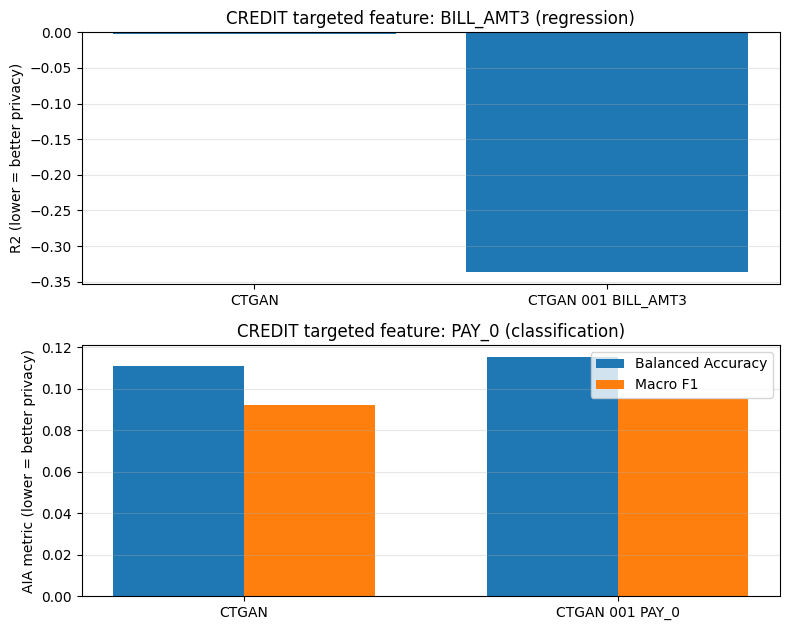

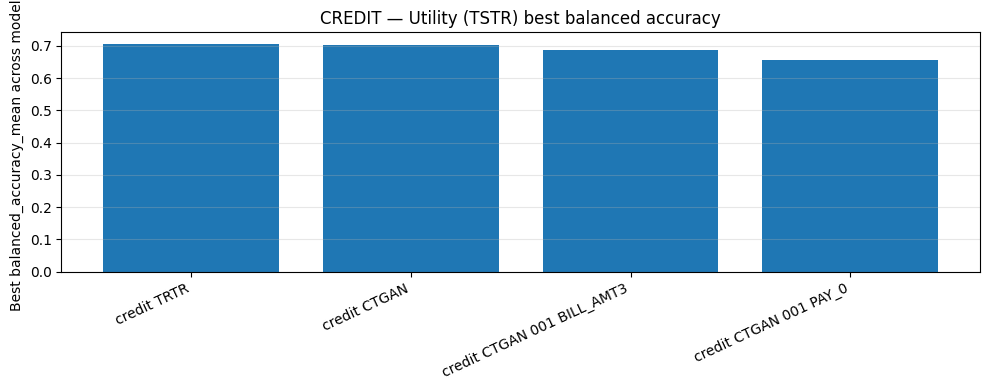

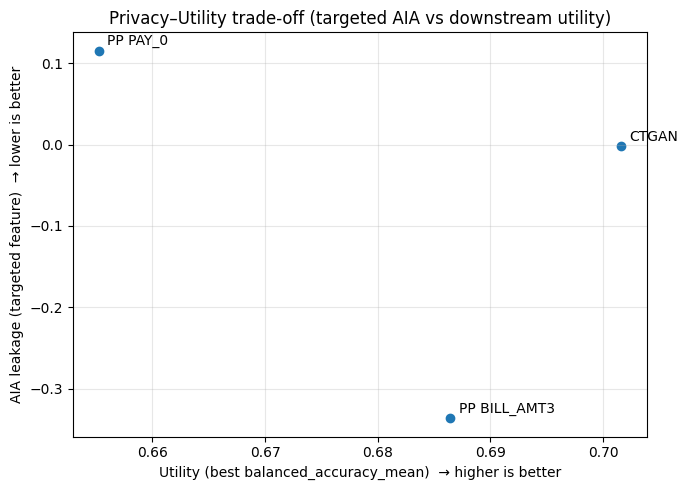

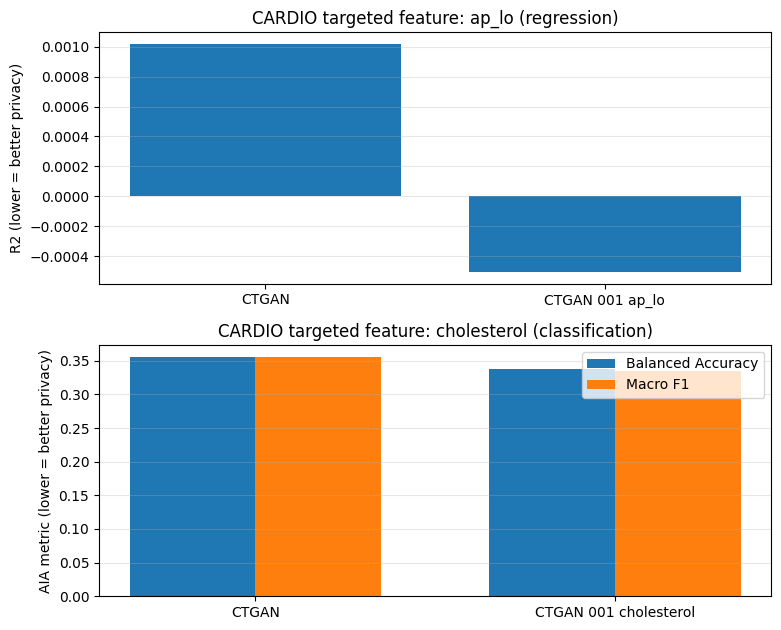

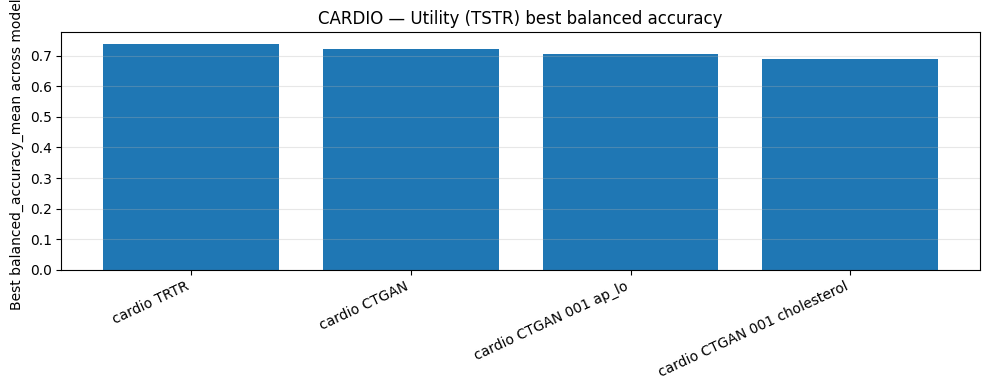

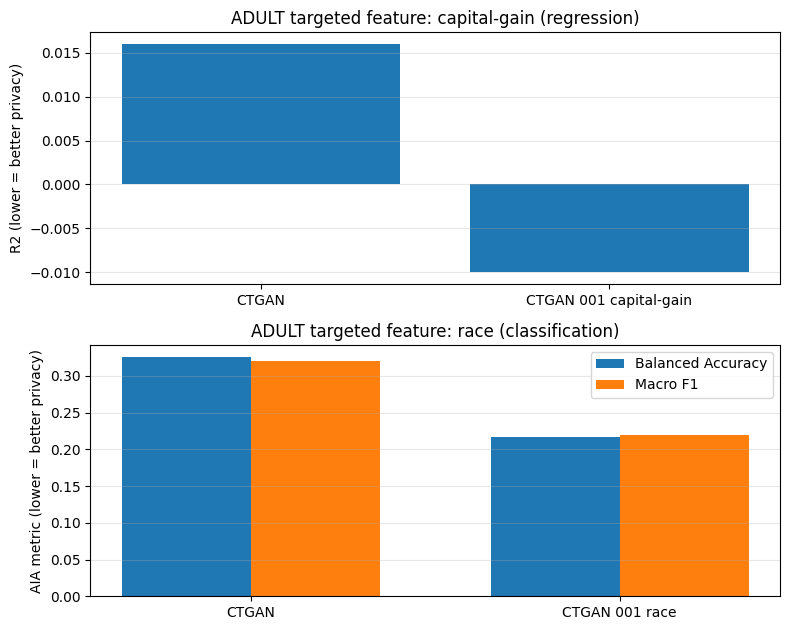

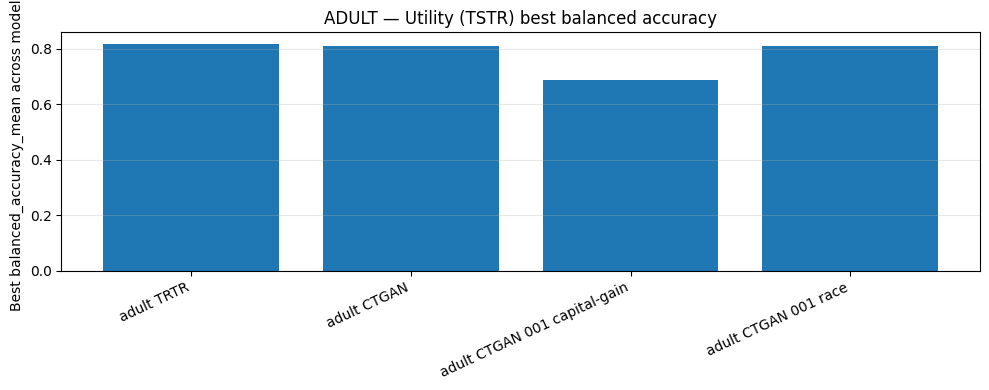

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helpers: parse AIA results
# ----------------------------

CLS_KEYS = ["Balanced Accuracy", "Macro F1", "Accuracy", "weighted F1"]
REG_KEYS = ["R2", "RMSE", "MSE"]

def _is_classification_metric(d: dict) -> bool:
    return any(k in d for k in CLS_KEYS)

def _is_regression_metric(d: dict) -> bool:
    return any(k in d for k in REG_KEYS)

def extract_aia_metric(aia_results: dict, method_key: str, feature: str, metric: str):
    """Return aia_results[method_key][feature][metric] or np.nan if missing."""
    try:
        return float(aia_results[method_key][feature][metric])
    except Exception:
        return np.nan

def infer_feature_type(aia_results: dict, method_key: str, feature: str):
    """Return 'cls' or 'reg' based on available keys."""
    d = aia_results.get(method_key, {}).get(feature, {})
    if not isinstance(d, dict):
        return None
    if _is_regression_metric(d):
        return "reg"
    if _is_classification_metric(d):
        return "cls"
    return None

# ----------------------------
# Helpers: parse Utility tables
# ----------------------------

def best_utility_score(utility_results: dict, method_key: str, metric: str = "balanced_accuracy_mean"):
    """
    Utility table is a DataFrame per method. We return max over models for the given metric.
    """
    df = utility_results.get(method_key, None)
    if df is None:
        return np.nan
    if metric not in df.columns:
        return np.nan
    return float(df[metric].max())

def best_utility_model(utility_results: dict, method_key: str, metric: str = "balanced_accuracy_mean"):
    df = utility_results.get(method_key, None)
    if df is None or metric not in df.columns:
        return None, np.nan
    idx = df[metric].idxmax()
    return str(idx), float(df.loc[idx, metric])

# ----------------------------
# Plot 1: Targeted AIA bars
# ----------------------------

def plot_targeted_aia_bars(aia_results, dataset_prefix, targets, metrics_cls=("Balanced Accuracy", "Macro F1"), metric_reg="R2"):
    """
    dataset_prefix: e.g. "credit", "adult", "cardio"
    targets: list of tuples (baseline_key, postproc_key, sensitive_feature)
      example: ("credit CTGAN", "credit CTGAN 001 PAY_0", "PAY_0")
    """
    n = len(targets)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 3.2 * n))
    if n == 1:
        axes = [axes]

    for ax, (base_key, pp_key, feat) in zip(axes, targets):
        ftype = infer_feature_type(aia_results, base_key, feat)
        labels = [base_key.replace(f"{dataset_prefix} ", ""), pp_key.replace(f"{dataset_prefix} ", "")]
        x = np.arange(len(labels))

        if ftype == "cls":
            width = 0.35
            vals = []
            for m in metrics_cls:
                vals_m = [
                    extract_aia_metric(aia_results, base_key, feat, m),
                    extract_aia_metric(aia_results, pp_key, feat, m),
                ]
                vals.append(vals_m)

            for i, (m, v) in enumerate(zip(metrics_cls, vals)):
                ax.bar(x + (i - (len(metrics_cls)-1)/2)*width, v, width, label=m)

            ax.set_ylabel("AIA metric (lower = better privacy)")
            ax.set_title(f"{dataset_prefix.upper()} targeted feature: {feat} (classification)")
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=0)
            ax.legend()

        elif ftype == "reg":
            vals = [
                extract_aia_metric(aia_results, base_key, feat, metric_reg),
                extract_aia_metric(aia_results, pp_key, feat, metric_reg),
            ]
            ax.bar(x, vals)
            ax.set_ylabel(f"{metric_reg} (lower = better privacy)")
            ax.set_title(f"{dataset_prefix.upper()} targeted feature: {feat} (regression)")
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=0)

        else:
            ax.text(0.5, 0.5, f"Cannot infer feature type for {feat}", ha="center", va="center")
            ax.set_axis_off()

        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Plot 2: Utility best-score bars
# ----------------------------

def plot_best_utility_bars(utility_results, methods, metric="balanced_accuracy_mean", title=None):
    scores = [best_utility_score(utility_results, k, metric=metric) for k in methods]
    labels = [k for k in methods]
    x = np.arange(len(labels))

    plt.figure(figsize=(10, 4))
    plt.bar(x, scores)
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel(f"Best {metric} across models")
    plt.title(title or f"Utility (best downstream model) — {metric}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Plot 3: Privacy–Utility scatter
# ----------------------------

def plot_privacy_utility_scatter(aia_results, utility_results, points, utility_metric="balanced_accuracy_mean",
                                cls_priv_metric="Balanced Accuracy", reg_priv_metric="R2"):
    """
    points: list of dicts with fields:
      - label
      - util_key (key in utility_results)
      - aia_key (key in aia_results)
      - sensitive_feature
    """
    xs, ys, labs = [], [], []
    for p in points:
        util = best_utility_score(utility_results, p["util_key"], metric=utility_metric)
        ftype = infer_feature_type(aia_results, p["aia_key"], p["sensitive_feature"])
        if ftype == "cls":
            leak = extract_aia_metric(aia_results, p["aia_key"], p["sensitive_feature"], cls_priv_metric)
        elif ftype == "reg":
            leak = extract_aia_metric(aia_results, p["aia_key"], p["sensitive_feature"], reg_priv_metric)
        else:
            leak = np.nan

        xs.append(util)
        ys.append(leak)
        labs.append(p["label"])

    plt.figure(figsize=(7, 5))
    plt.scatter(xs, ys)
    for x, y, t in zip(xs, ys, labs):
        plt.annotate(t, (x, y), textcoords="offset points", xytext=(6, 4))

    plt.xlabel(f"Utility (best {utility_metric})  → higher is better")
    plt.ylabel("AIA leakage (targeted feature)  → lower is better")
    plt.title("Privacy–Utility trade-off (targeted AIA vs downstream utility)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------
# HOW TO CALL IT FOR YOUR EXPERIMENTS
# ----------------------------

# Credit targets (you have BILL_AMT3 as numeric target and PAY_0 as categorical target)
credit_targets = [
    ("credit CTGAN", "credit CTGAN 001 BILL_AMT3", "BILL_AMT3"),
    ("credit CTGAN", "credit CTGAN 001 PAY_0", "PAY_0"),
]

plot_targeted_aia_bars(aia_results, "credit", credit_targets)

credit_methods_for_utility = [
    "credit TRTR",
    "credit CTGAN",
    "credit CTGAN 001 BILL_AMT3",
    "credit CTGAN 001 PAY_0",
]
plot_best_utility_bars(
    utility_results,
    credit_methods_for_utility,
    metric="balanced_accuracy_mean",
    title="CREDIT — Utility (TSTR) best balanced accuracy",
)

credit_points = [
    {"label": "CTGAN", "util_key": "credit CTGAN", "aia_key": "credit CTGAN", "sensitive_feature": "BILL_AMT3"},
    {"label": "PP BILL_AMT3", "util_key": "credit CTGAN 001 BILL_AMT3", "aia_key": "credit CTGAN 001 BILL_AMT3", "sensitive_feature": "BILL_AMT3"},
    {"label": "PP PAY_0", "util_key": "credit CTGAN 001 PAY_0", "aia_key": "credit CTGAN 001 PAY_0", "sensitive_feature": "PAY_0"},
]
plot_privacy_utility_scatter(aia_results, utility_results, credit_points)

# Cardio targets
cardio_targets = [
    ("cardio CTGAN", "cardio CTGAN 001 ap_lo", "ap_lo"),
    ("cardio CTGAN", "cardio CTGAN 001 cholesterol", "cholesterol"),
]
plot_targeted_aia_bars(aia_results, "cardio", cardio_targets)

cardio_methods_for_utility = [
    "cardio TRTR",
    "cardio CTGAN",
    "cardio CTGAN 001 ap_lo",
    "cardio CTGAN 001 cholesterol",
]
plot_best_utility_bars(
    utility_results,
    cardio_methods_for_utility,
    metric="balanced_accuracy_mean",
    title="CARDIO — Utility (TSTR) best balanced accuracy",
)

# Adult targets
adult_targets = [
    ("adult CTGAN", "adult CTGAN 001 capital-gain", "capital-gain"),
    ("adult CTGAN", "adult CTGAN 001 race", "race"),
]
plot_targeted_aia_bars(aia_results, "adult", adult_targets)

adult_methods_for_utility = [
    "adult TRTR",
    "adult CTGAN",
    "adult CTGAN 001 capital-gain",
    "adult CTGAN 001 race",
]
plot_best_utility_bars(
    utility_results,
    adult_methods_for_utility,
    metric="balanced_accuracy_mean",
    title="ADULT — Utility (TSTR) best balanced accuracy",
)


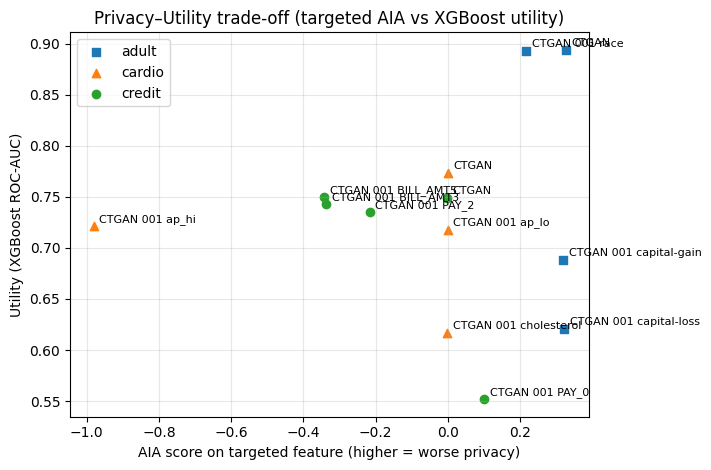

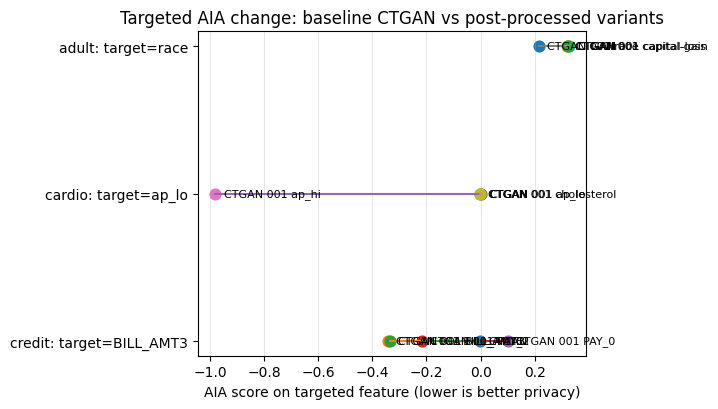

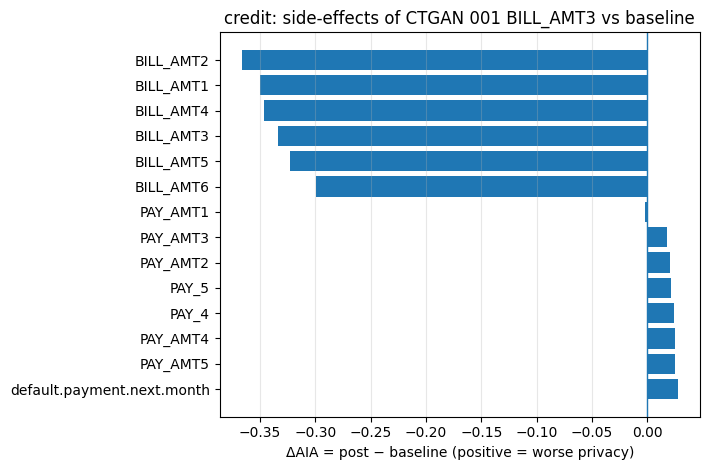

In [31]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Helpers: parse "release key"
# ----------------------------
def parse_release_key(key: str):
    """
    Examples:
      "credit CTGAN" -> dataset=credit, variant=CTGAN, target=None
      "credit CTGAN 001 BILL_AMT3" -> dataset=credit, variant=CTGAN_001, target=BILL_AMT3
      "credit TRTR" -> dataset=credit, variant=TRTR, target=None
    """
    parts = key.split()
    dataset = parts[0]
    if "TRTR" in parts:
        return dataset, "TRTR", None
    if len(parts) >= 2 and parts[1] == "CTGAN":
        if len(parts) == 2:
            return dataset, "CTGAN", None
        # "CTGAN 001 <TARGET>"
        if len(parts) >= 4 and parts[2] == "001":
            return dataset, "CTGAN_001", parts[3]
    # fallback
    return dataset, "UNKNOWN", None


# ----------------------------
# 1) Flatten AIA results
# ----------------------------
def flatten_aia(aia_results: dict) -> pd.DataFrame:
    rows = []
    for release_key, feat_dict in aia_results.items():
        dataset, variant, target = parse_release_key(release_key)
        for feature, metrics in feat_dict.items():
            row = {
                "release": release_key,
                "dataset": dataset,
                "variant": variant,
                "target": target,
                "feature": feature,
            }
            # Classification vs regression (based on available keys)
            if "Balanced Accuracy" in metrics:
                row["aia_task"] = "classification"
                row["aia_score"] = float(metrics["Balanced Accuracy"])  # higher = worse privacy
                row["macro_f1"] = float(metrics.get("Macro F1", np.nan))
                row["acc"] = float(metrics.get("Accuracy", np.nan))
            elif "R2" in metrics:
                row["aia_task"] = "regression"
                row["aia_score"] = float(metrics["R2"])  # higher = worse privacy
                row["rmse"] = float(metrics.get("RMSE", np.nan))
                row["mse"] = float(metrics.get("MSE", np.nan))
            else:
                row["aia_task"] = "unknown"
                row["aia_score"] = np.nan

            rows.append(row)
    return pd.DataFrame(rows)


# ----------------------------
# 2) Extract XGBoost utility
# ----------------------------
def extract_xgb_utility(utility_results: dict, metric: str = "roc_auc_mean") -> pd.DataFrame:
    """
    utility_results: dict[str -> pd.DataFrame], where rows are models (CART, ... XGBoost)
    metric: e.g. "roc_auc_mean" or "balanced_accuracy_mean" or "accuracy_mean"
    """
    rows = []
    for release_key, df in utility_results.items():
        dataset, variant, target = parse_release_key(release_key)
        if "XGBoost" not in df.index:
            continue
        if metric not in df.columns:
            raise KeyError(f"Metric {metric!r} not in columns. Available: {list(df.columns)}")

        rows.append({
            "release": release_key,
            "dataset": dataset,
            "variant": variant,
            "target": target,
            "utility_metric": metric,
            "utility": float(df.loc["XGBoost", metric]),
            "utility_std": float(df.loc["XGBoost", metric.replace("_mean", "_std")] ) if metric.endswith("_mean") and metric.replace("_mean","_std") in df.columns else np.nan,
        })
    return pd.DataFrame(rows)


# ----------------------------
# 3) Plot 1: Privacy–Utility frontier (targeted feature)
# ----------------------------
def plot_frontier(aia_df, util_df, targeted_by_dataset: dict, utility_metric_name: str, title: str):
    """
    targeted_by_dataset: {"credit": "BILL_AMT3", "adult": "race", "cardio": "cholesterol"} etc.
    Uses AIA score on that targeted feature.
    """
    # pick AIA rows where feature == target feature for each dataset
    a = []
    for ds, feat in targeted_by_dataset.items():
        sub = aia_df[(aia_df["dataset"] == ds) & (aia_df["feature"] == feat)]
        a.append(sub)
    a = pd.concat(a, ignore_index=True)

    # merge with utility
    m = a.merge(util_df[["release","utility"]], on="release", how="inner")

    plt.figure(figsize=(7.2, 4.8))
    # plot per dataset with different markers (simple)
    markers = {"credit":"o", "adult":"s", "cardio":"^"}
    for ds in sorted(m["dataset"].unique()):
        sub = m[m["dataset"] == ds]
        plt.scatter(sub["aia_score"], sub["utility"], marker=markers.get(ds,"o"), label=ds)

        # label points (short labels)
        for _, r in sub.iterrows():
            short = r["release"].replace(ds+" ", "")
            plt.annotate(short, (r["aia_score"], r["utility"]), fontsize=8, xytext=(4, 3), textcoords="offset points")

    plt.xlabel("AIA score on targeted feature (higher = worse privacy)")
    plt.ylabel(f"Utility (XGBoost {utility_metric_name})")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


# ----------------------------
# 4) Plot 2: Dumbbell (baseline CTGAN vs best postprocess)
# ----------------------------
def plot_dumbbell_target(aia_df, targeted_by_dataset: dict, title: str):
    """
    For each dataset: show AIA(target feature) for CTGAN vs each postprocess;
    emphasis on before/after.
    """
    plt.figure(figsize=(7.2, 4.2))
    y_positions = []
    y_labels = []
    i = 0

    for ds, feat in targeted_by_dataset.items():
        sub = aia_df[(aia_df["dataset"] == ds) & (aia_df["feature"] == feat)]

        base = sub[sub["variant"] == "CTGAN"]
        if base.empty:
            continue
        base_score = float(base["aia_score"].iloc[0])

        posts = sub[sub["variant"] == "CTGAN_001"].copy()
        posts = posts.sort_values("aia_score")  # best privacy first (lowest score)

        # baseline point
        y = i
        plt.scatter([base_score], [y], s=60)
        plt.annotate("CTGAN", (base_score, y), fontsize=8, xytext=(6, 0), textcoords="offset points", va="center")

        # connect to each postprocess
        for _, r in posts.iterrows():
            post_score = float(r["aia_score"])
            plt.plot([base_score, post_score], [y, y], linewidth=1.5)
            plt.scatter([post_score], [y], s=60)
            label = r["release"].replace(ds+" ", "")
            plt.annotate(label, (post_score, y), fontsize=8, xytext=(6, 0), textcoords="offset points", va="center")

        y_positions.append(y)
        y_labels.append(f"{ds}: target={feat}")
        i += 1

    plt.yticks(y_positions, y_labels)
    plt.xlabel("AIA score on targeted feature (lower is better privacy)")
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()


# ----------------------------
# 5) Plot 3: ΔAIA side-effects (post - baseline) across features
# ----------------------------
def plot_delta_aia_side_effects(aia_df, dataset: str, post_release: str, baseline_release: str, top_k: int = 12):
    """
    Shows features whose AIA changed the most.
    ΔAIA = AIA(post) - AIA(baseline). Positive => privacy got worse.
    """
    base = aia_df[(aia_df["release"] == baseline_release)][["feature","aia_score"]].rename(columns={"aia_score":"aia_base"})
    post = aia_df[(aia_df["release"] == post_release)][["feature","aia_score"]].rename(columns={"aia_score":"aia_post"})

    d = post.merge(base, on="feature", how="inner")
    d["delta"] = d["aia_post"] - d["aia_base"]
    d = d.sort_values("delta", ascending=False)

    # keep top worsened + top improved
    head = d.head(top_k//2)
    tail = d.tail(top_k//2)
    s = pd.concat([head, tail], axis=0)

    plt.figure(figsize=(7.2, 4.8))
    plt.barh(s["feature"], s["delta"])
    plt.axvline(0.0, linewidth=1.0)
    plt.xlabel("ΔAIA = post − baseline (positive = worse privacy)")
    plt.title(f"{dataset}: side-effects of {post_release.replace(dataset+' ','')} vs baseline")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()


# ----------------------------
# Example usage (adapt targets)
# ----------------------------
aia_df = flatten_aia(aia_results)

# Choose your utility metric for the frontier:
# - classification tasks: "roc_auc_mean" is usually best if available
# - alternatively "balanced_accuracy_mean"
util_df = extract_xgb_utility(utility_results, metric="roc_auc_mean")

# Targets you actually care about (examples from your description)
targeted_by_dataset = {
    "credit": "BILL_AMT3",      # numeric targeted example
    "cardio": "ap_lo",          # numeric targeted example
    "adult": "race",            # categorical targeted example
}

plot_frontier(
    aia_df, util_df,
    targeted_by_dataset=targeted_by_dataset,
    utility_metric_name="ROC-AUC",
    title="Privacy–Utility trade-off (targeted AIA vs XGBoost utility)"
)
plt.show()

plot_dumbbell_target(
    aia_df,
    targeted_by_dataset=targeted_by_dataset,
    title="Targeted AIA change: baseline CTGAN vs post-processed variants"
)
plt.show()

# Side-effect example (credit, postprocess BILL_AMT3 vs baseline CTGAN)
plot_delta_aia_side_effects(
    aia_df,
    dataset="credit",
    post_release="credit CTGAN 001 BILL_AMT3",
    baseline_release="credit CTGAN",
    top_k=14
)
plt.show()


In [17]:
aia_results = {
    # CREDIT
    "credit CTGAN": {
        "BILL_AMT1": {"R2": -0.009138965996587256},
        "BILL_AMT2": {"R2": -0.003168240636175934},
        "BILL_AMT3": {"R2": -0.0022512981261919585},
        "BILL_AMT4": {"R2": -0.003271977995257247},
        "BILL_AMT5": {"R2": -0.00023720475658906004},
        "BILL_AMT6": {"R2": -0.0037639396026660776},
        "PAY_0": {"Balanced Accuracy": 0.11073471828500459, "Accuracy": 0.44316666666666665},
        "PAY_2": {"Balanced Accuracy": 0.12248680658459637, "Accuracy": 0.4518333333333333},
        "PAY_4": {"Balanced Accuracy": 0.10449028687396211, "Accuracy": 0.5253333333333333},
        "PAY_AMT1": {"R2": -0.0006529948986597756},
        "PAY_AMT4": {"R2": 0.0023696653714344595},
        "default.payment.next.month": {"Balanced Accuracy": 0.5072009712008275, "Accuracy": 0.7401666666666666},
    },
    "credit CTGAN 001 BILL_AMT3": {
        "BILL_AMT1": {"R2": -0.35927969965966233},
        "BILL_AMT2": {"R2": -0.3696788116816021},
        "BILL_AMT3": {"R2": -0.3361483131031964},
        "BILL_AMT4": {"R2": -0.3494368638108123},
        "BILL_AMT5": {"R2": -0.32330771035436534},
        "BILL_AMT6": {"R2": -0.30276271108957875},
        "PAY_0": {"Balanced Accuracy": 0.12402896634779162, "Accuracy": 0.25533333333333336},
        "PAY_2": {"Balanced Accuracy": 0.14027559953006855, "Accuracy": 0.2788333333333333},
        "PAY_4": {"Balanced Accuracy": 0.12821598010927784, "Accuracy": 0.3233333333333333},
        "PAY_AMT1": {"R2": -0.002792561735340593},
        "PAY_AMT4": {"R2": 0.026971573118457104},
        "default.payment.next.month": {"Balanced Accuracy": 0.5349701683335687, "Accuracy": 0.754},
    },
    "credit CTGAN 001 PAY_0": {
        "PAY_0": {"Balanced Accuracy": 0.11528323984899343, "Accuracy": 0.4741666666666667},
    },

    # ADULT
    "adult CTGAN": {
        "capital-gain": {"R2": 0.01603487323636854},
        "race": {"Balanced Accuracy": 0.32584966339554866, "Accuracy": 0.8127879122903998},
    },
    "adult CTGAN 001 capital-gain": {
        "capital-gain": {"R2": -0.010010605558565588},
    },
    "adult CTGAN 001 race": {
        "race": {"Balanced Accuracy": 0.21654896699307638, "Accuracy": 0.8307229285670413},
    },

    # CARDIO
    "cardio CTGAN": {
        "ap_lo": {"R2": 0.0010199086435125349},
        "cholesterol": {"Balanced Accuracy": 0.35495560773116946, "Accuracy": 0.6186666666666667},
    },
    "cardio CTGAN 001 ap_lo": {
        "ap_lo": {"R2": -0.0005087108241927929},
    },
    "cardio CTGAN 001 cholesterol": {
        "cholesterol": {"Balanced Accuracy": 0.3380593343748725, "Accuracy": 0.6280476190476191},
    },
}

utility_results = {
    # CREDIT
    "credit TRTR": {"roc_auc_mean": 0.779165, "roc_auc_std": 0.001080,
                    "log_loss_mean": 0.429458, "log_loss_std": 0.000829},
    "credit CTGAN": {"roc_auc_mean": 0.749085, "roc_auc_std": 0.001170,
                     "log_loss_mean": 0.453075, "log_loss_std": 0.000817},
    "credit CTGAN 001 BILL_AMT3": {"roc_auc_mean": 0.743069, "roc_auc_std": 0.003010,
                                  "log_loss_mean": 0.455976, "log_loss_std": 0.002099},
    "credit CTGAN 001 PAY_0": {"roc_auc_mean": 0.551742, "roc_auc_std": 0.003648,
                              "log_loss_mean": 0.624101, "log_loss_std": 0.005398},

    # ADULT
    "adult TRTR": {"roc_auc_mean": 0.928188, "roc_auc_std": 0.000216,
                   "log_loss_mean": 0.275101, "log_loss_std": 0.000371},
    "adult CTGAN": {"roc_auc_mean": 0.894164, "roc_auc_std": 0.000424,
                    "log_loss_mean": 0.335710, "log_loss_std": 0.000416},
    "adult CTGAN 001 capital-gain": {"roc_auc_mean": 0.687822, "roc_auc_std": 0.002690,
                                     "log_loss_mean": 1.025614, "log_loss_std": 0.003717},
    "adult CTGAN 001 race": {"roc_auc_mean": 0.892697, "roc_auc_std": 0.000381,
                             "log_loss_mean": 0.337513, "log_loss_std": 0.000552},

    # CARDIO
    "cardio TRTR": {"roc_auc_mean": 0.801364, "roc_auc_std": 0.000173,
                    "log_loss_mean": 0.542771, "log_loss_std": 0.000205},
    "cardio CTGAN": {"roc_auc_mean": 0.773771, "roc_auc_std": 0.000599,
                     "log_loss_mean": 0.573973, "log_loss_std": 0.000528},
    "cardio CTGAN 001 ap_lo": {"roc_auc_mean": 0.717855, "roc_auc_std": 0.000672,
                               "log_loss_mean": 0.777589, "log_loss_std": 0.005326},
    "cardio CTGAN 001 cholesterol": {"roc_auc_mean": 0.616651, "roc_auc_std": 0.002253,
                                     "log_loss_mean": 0.874381, "log_loss_std": 0.008907},
}
